In [16]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

## 1. Import data.

Make sure all the files are in the working directory.

In [2]:
csv_paths = list(Path("datasets/data_old_approach/").glob("*.csv"))

print("CSV files found:")
for p in csv_paths:
    print(p.name)

CSV files found:
bank_of_america__combined_us.csv
chase__combined_us.csv
citi__combined_us.csv
marcus_by_goldman_sachs__combined_us.csv
wells_fargo__combined_us.csv


In [3]:
csv_paths = list(Path("datasets/data_old_approach/").glob("*.csv"))

if len(csv_paths) == 0:
    raise FileNotFoundError(
        f"No CSVs found in data_raw/. Move your combined CSVs into: {Path.cwd() / DATA_RAW}"
    )

In [4]:
# import files
raw = pd.concat(
    [
        pd.read_csv(p, dtype=str).assign(source_file=p.name)
        for p in csv_paths
    ],
    ignore_index=True
)

## 2. Data Overview

In [5]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5450 entries, 0 to 5449
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   platform       5450 non-null   object
 1   storefront     5450 non-null   object
 2   app_id         2450 non-null   object
 3   review_id      5450 non-null   object
 4   date           5450 non-null   object
 5   user           5450 non-null   object
 6   rating         5450 non-null   object
 7   title          2450 non-null   object
 8   review         5450 non-null   object
 9   version        2450 non-null   object
 10  package        3000 non-null   object
 11  thumbsUpCount  3000 non-null   object
 12  appVersion     2717 non-null   object
 13  source_file    5450 non-null   object
dtypes: object(14)
memory usage: 596.2+ KB


In [7]:
raw.describe(include = "all")

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
count,5450,5450,2450,5450,5450,5450,5450,2450,5450,2450,3000,3000,2717,5450
unique,2,1,5,5450,5449,5404,5,2058,4929,55,5,29,93,5
top,google_play,us,284847138.0,13566342702,2025-12-17 16:42:21,A Google user,5,Easy to use,good,25.10.04,com.infonow.bofa,0.0,9.90.0,bank_of_america__combined_us.csv
freq,3000,5450,490,1,2,16,3032,17,47,268,600,2623,508,1090


In [9]:
raw.head()

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,us,284847138.0,13566342702,2025-12-28T13:28:49-07:00,EBP1940,1,Horrible.,I can’t load the banking app bc it requires a ...,25.04.06,NaN,NaN,NaN,bank_of_america__combined_us.csv
1,app_store,us,284847138.0,13566341104,2025-12-28T13:28:13-07:00,papemahi,5,Enjoy,Good\nGood,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv
2,app_store,us,284847138.0,13566049201,2025-12-28T11:48:52-07:00,Jiankun Li,5,Bank Of America Application Benefit,Bank Of America has an application which allow...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv
3,app_store,us,284847138.0,13565792340,2025-12-28T10:27:09-07:00,Tom nrady,5,App,The app is easy to use for a 63-year-old woman...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv
4,app_store,us,284847138.0,13564879934,2025-12-28T05:55:07-07:00,Banco América,5,Mi banco,Muy bien,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv


In [10]:
platform_counts = (
    raw
    .groupby("platform")
    .size()
    .reset_index(name="n_reviews")
)

platform_counts

,platform,n_reviews
0,app_store,2450
1,google_play,3000


In [11]:
missing_raw = (
    raw
    .isna()
    .sum()
    .reset_index()
)

missing_raw.columns = ["variable", "n_missing"]

missing_raw = (
    missing_raw
    .sort_values("n_missing", ascending=False)
    .reset_index(drop=True)
)

missing_raw

,variable,n_missing
0,app_id,3000
1,title,3000
2,version,3000
3,appVersion,2733
4,package,2450
5,thumbsUpCount,2450
6,platform,0
7,storefront,0
8,review_id,0
9,date,0


In [12]:
missing_by_platform = (
    raw
    .groupby("platform")
    .agg(lambda col: col.isna().sum())
    .reset_index()
)

missing_by_platform

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,0,0,0,0,0,0,0,0,0,2450,2450,2450,0
1,google_play,0,3000,0,0,0,0,3000,0,3000,0,0,283,0


In [13]:
raw["raw_text"] = (
    raw["title"].fillna("") + " " + raw["review"].fillna("")
)

raw["raw_length_words"] = (
    raw["raw_text"]
    .str.count(r"\S+")
)

In [14]:
raw["raw_length_words"].describe()

count    5450.000000
mean       22.933394
std        30.588918
min         1.000000
25%         4.000000
50%        12.000000
75%        30.000000
max       411.000000
Name: raw_length_words, dtype: float64

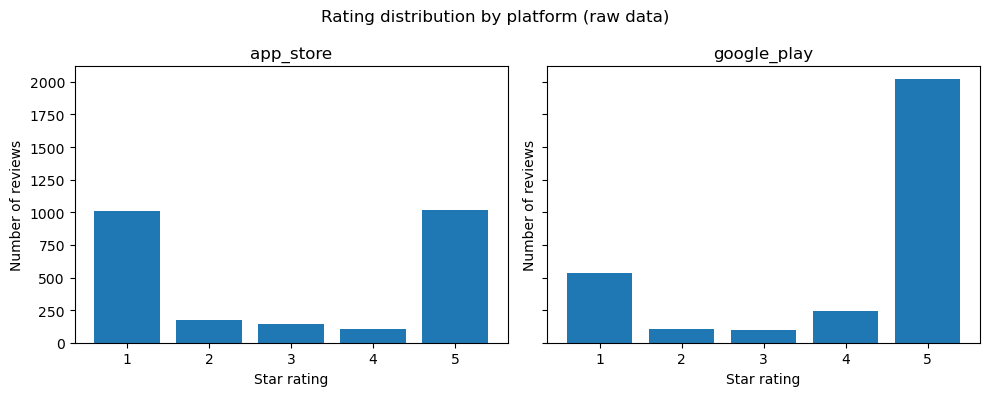

In [ ]:
# Count the ratings by platform
rating_counts = (
    raw
    .groupby(["platform", "rating"])
    .size()
    .reset_index(name="n_reviews")
)

# Create one bar chart per platform
platforms = rating_counts["platform"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(platforms),
    figsize=(10, 4),
    sharey=True
)

# If there is only one platform, make axes iterable
if len(platforms) == 1:
    axes = [axes]

for ax, platform in zip(axes, platforms):
    data = rating_counts[rating_counts["platform"] == platform]

    ax.bar(data["rating"], data["n_reviews"])
    ax.set_title(platform)
    ax.set_xlabel("Star rating")
    ax.set_ylabel("Number of reviews")

fig.suptitle("Rating distribution by platform (raw data)")
plt.tight_layout()
plt.show()